In [1]:
import pandas as pd
import numpy as numpy
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/Salary_Data.csv')

### Single Column is called a series
### Single row is called a record, field

In [3]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


In [4]:
# Initial 5 records
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [5]:
# Last 5 records
df.tail()

,YearsExperience,Salary
25,9.0,105582.0
26,9.5,116969.0
27,9.6,112635.0
28,10.3,122391.0
29,10.5,121872.0


In [6]:
# Retrieve random sample of 5 records
df.sample(5)

,YearsExperience,Salary
22,7.9,101302.0
20,6.8,91738.0
11,4.0,55794.0
5,2.9,56642.0
27,9.6,112635.0


In [7]:
df.columns

Index(['YearsExperience', 'Salary'], dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [9]:
# only shows descriptive statistics for numeric columns
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [10]:
df['YearsExperience'].mean()  # Mean of YearsExperience column

5.3133333333333335

In [11]:
df['YearsExperience'].describe()  # Descriptive statistics for YearsExperience column

count    30.000000
mean      5.313333
std       2.837888
min       1.100000
25%       3.200000
50%       4.700000
75%       7.700000
max      10.500000
Name: YearsExperience, dtype: float64

In [12]:
df['YearsExperience'].std()  # Standard deviation of YearsExperience column

2.8378881576627184

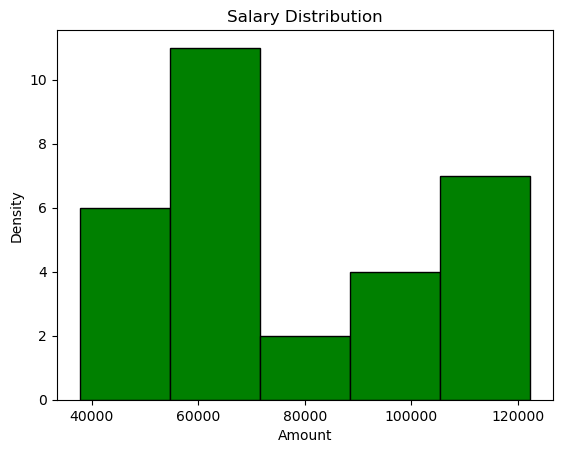

In [13]:
plt.title('Salary Distribution')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.hist(df['Salary'], bins=5, edgecolor='black', color='green')
plt.show()

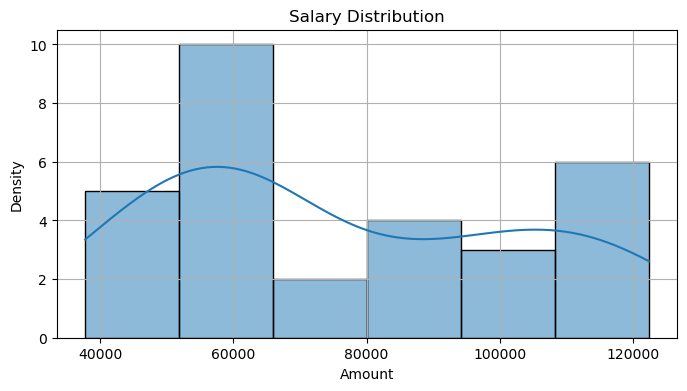

In [14]:
# Univariate analysis of (One) Salary column

plt.figure(figsize=(8, 4))
plt.title('Salary Distribution')
plt.xlabel('Amount')
plt.ylabel('Density')
sns.histplot(df['Salary'], kde=True)
plt.grid(True)
plt.savefig('salary_distribution_histogram.png')
plt.show()

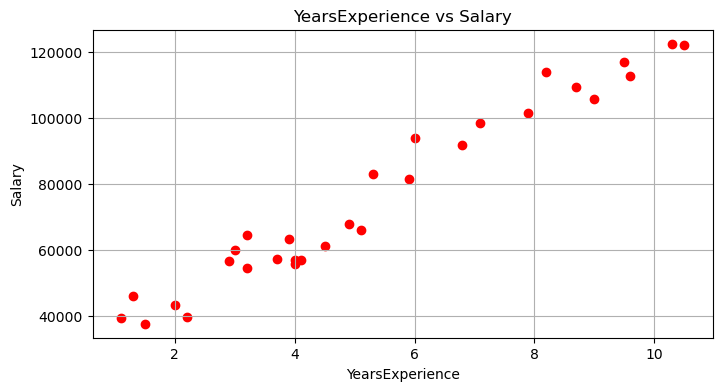

In [15]:
# Bivariate analysis of (Two) YearsExperience and Salary columns
plt.figure(figsize=(8, 4))
plt.title('YearsExperience vs Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.scatter(df['YearsExperience'], df['Salary'], color='red')
plt.grid(True)
plt.show()

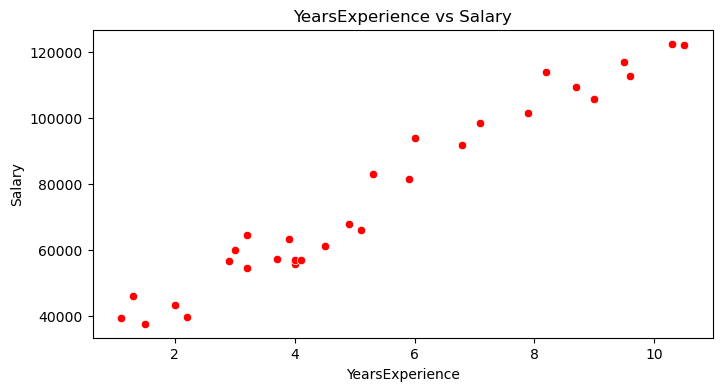

In [16]:
# Bivariate analysis of (Two) YearsExperience and Salary columns
plt.figure(figsize=(8, 4))
sns.scatterplot(x='YearsExperience', y='Salary', data=df, color='red')
plt.title('YearsExperience vs Salary')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.show()

In [17]:
correlation = df['YearsExperience'].corr(df['Salary'])
print(f"Correlation between YearsExperience and Salary: {correlation}")

Correlation between YearsExperience and Salary: 0.9782416184887599


## Lecture # 3
### Test, Train ML Linear Regression

### separate input and output columns

In [18]:
X=df.drop(columns=['Salary'])
y=df['Salary']

In [19]:
X

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [20]:
y

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

## Creating model

In [22]:
from sklearn.linear_model import LinearRegression

In [23]:
reg = LinearRegression()

In [24]:
reg.fit(x_train,y_train)

LinearRegression()

### Test model

In [25]:
# predict
y_pred = reg.predict(x_test)
y_pred

array([ 40748.96184072, 122699.62295594,  64961.65717022,  63099.14214487,
       115249.56285456, 107799.50275317])

In [26]:
pd.DataFrame({'y_test':y_test, 'y_pred':y_pred,"MAE":(y_test-y_pred)})

,y_test,y_pred,MAE
2,37731.0,40748.961841,-3017.961841
28,122391.0,122699.622956,-308.622956
13,57081.0,64961.657170,-7880.657170
10,63218.0,63099.142145,118.857855
26,116969.0,115249.562855,1719.437145
24,109431.0,107799.502753,1631.497247


### Model intercept and slope, make an equation

In [27]:
# take out model intercept and slop, make an equation
print(reg.intercept_)
print(reg.coef_)
print('y = ',reg.coef_, '* X', '+', reg.intercept_)

26780.099150628186
[9312.57512673]
y =  [9312.57512673] * X + 26780.099150628186


### Evaluation Matrix

In [28]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

In [29]:
print('MSE = ', mean_squared_error(y_test, y_pred ))
print('RMSE = ', np.sqrt(mean_squared_error(y_test, y_pred )))
print('R2 = ', r2_score(y_test, y_pred ))

MSE =  12823412.298126562
RMSE =  3580.979237321345
R2 =  0.988169515729126


### Plot Model on Train and Test data

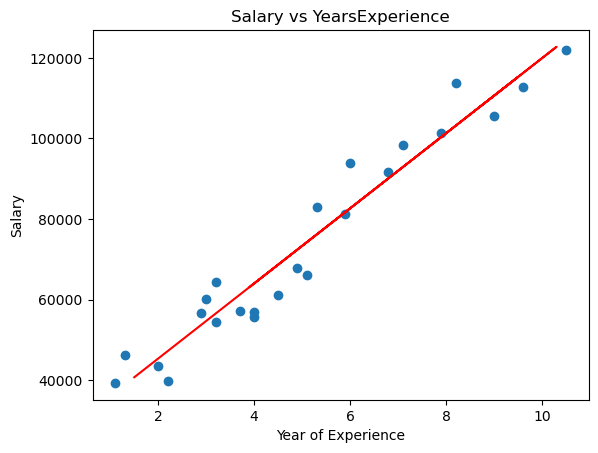

In [30]:
plt.scatter(x_train,y_train)
plt.plot(x_test,y_pred,color='r')
plt.title("Salary vs YearsExperience")
plt.xlabel("Year of Experience")
plt.ylabel("Salary")
plt.show()

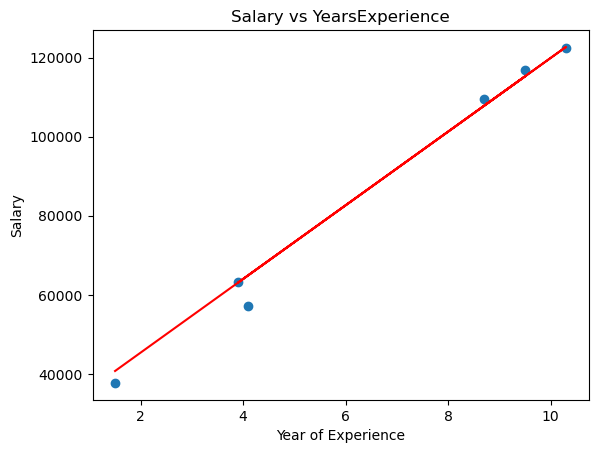

In [31]:
plt.scatter(x_test,y_test)
plt.plot(x_test,y_pred,color='r')
plt.title("Salary vs YearsExperience")
plt.xlabel("Year of Experience")
plt.ylabel("Salary")
plt.show()

In [32]:
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [ ]:
reg.predict([[8]])  # Predicting salary for 8 years of experience

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([101280.70016446])

In [34]:
reg.predict([[1.5]])  # Predicting salary for 1.5 years of experience   

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40748.96184072])